# LSTM

# Yelp

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Epoch 1, Train Acc: 0.5288, Val Acc: 0.5836, Test Acc: 0.5978
Epoch 2, Train Acc: 0.5949, Val Acc: 0.6283, Test Acc: 0.6367
Epoch 3, Train Acc: 0.6149, Val Acc: 0.6397, Test Acc: 0.6614
Epoch 4, Train Acc: 0.6252, Val Acc: 0.6592, Test Acc: 0.6669
Epoch 5, Train Acc: 0.6378, Val Acc: 0.6561, Test Acc: 0.6800
Epoch 6, Train Acc: 0.6501, Val Acc: 0.6622, Test Acc: 0.6761
Epoch 7, Train Acc: 0.6604, Val Acc: 0.6614, Test Acc: 0.6744
Epoch 8, Train Acc: 0.6728, Val Acc: 0.6664, Test Acc: 0.6953
Epoch 9, Train Acc: 0.6841, Val Acc: 0.6728, Test Acc: 0.6983
Epoch 10, Train Acc: 0.6930, Val Acc: 0.6722, Test Acc: 0.6933
Epoch 11, Train Acc: 0.7042, Val Acc: 0.6808, Test Acc: 0.7044
Epoch 12, Train Acc: 0.7158, Val Acc: 0.6753, Test Acc: 0.7050
Epoch 13, Train Acc: 0.7273, Val Acc: 0.6656, Test Acc: 0.6819
Epoch 14, Train Acc: 0.7389, Val Acc: 0.6669, Test Acc: 0.6858
Epoch 15, Train Acc: 0.7530, Val Acc: 0.6667, Test Acc: 0.6819
Epoch 16, Train Acc: 0.7670, Val Acc: 0.6681, Test Acc: 0.6850
E

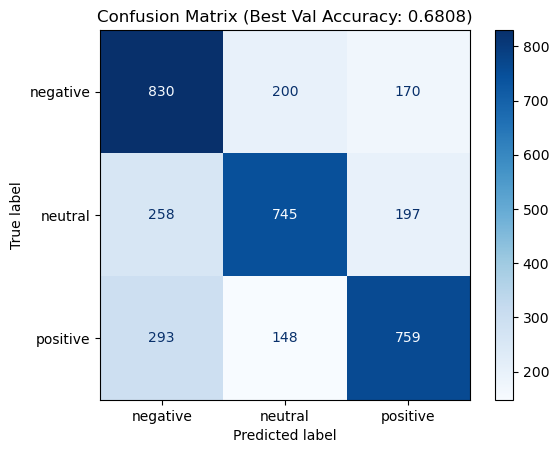

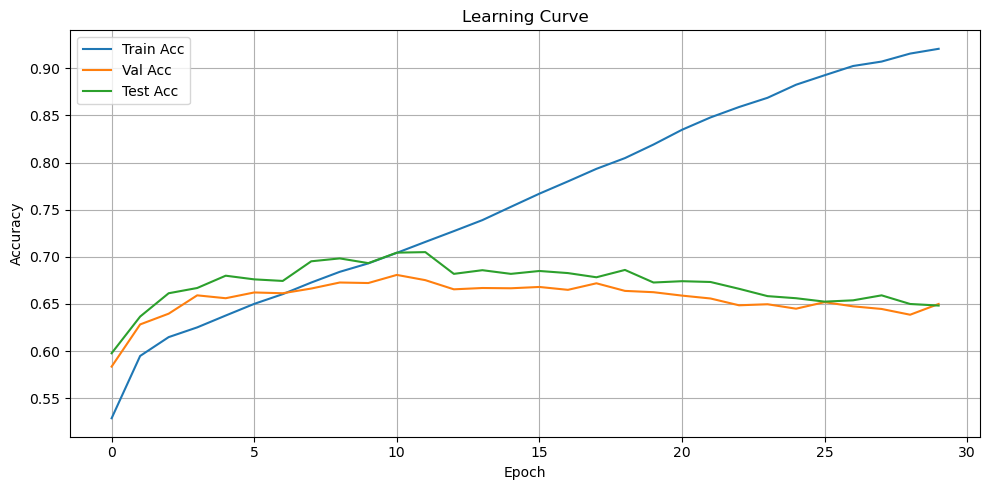

In [5]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

# ------------------- NLTK Setup -------------------
for resource in ['punkt', 'wordnet', 'averaged_perceptron_tagger']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource)

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('N'): return wordnet.NOUN
    elif tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def tokenize_text(text):
    tokens = word_tokenize(text.lower())
    return [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tag(tokens)]

# ------------------- Load Data -------------------
train_file = "/Users/tejamallireddy/Downloads/yelp/train.csv"
val_file = "/Users/tejamallireddy/Downloads/yelp/dev.csv"
test_file = "/Users/tejamallireddy/Downloads/yelp/test.csv"

def load_data(train_file, val_file, test_file):
    train_df = pd.read_csv(train_file)[['text', 'label']].dropna()
    val_df = pd.read_csv(val_file)[['text', 'label']].dropna()
    test_df = pd.read_csv(test_file)[['text', 'label']].dropna()
    return train_df, val_df, test_df

data_train, data_val, data_test = load_data(train_file, val_file, test_file)

# ------------------- Preprocess -------------------
for df in [data_train, data_val, data_test]:
    df['tokenized_text'] = df['text'].apply(tokenize_text)
    df['untokenized_text'] = df['tokenized_text'].apply(lambda x: " ".join(x))

# ➕ TF-IDF (optional)
vectorizer = TfidfVectorizer(max_features=5000)
vectorizer.fit(data_train['untokenized_text'])

# ------------------- Build Vocabulary -------------------
def build_vocab(texts):
    vocab = {}
    for text in texts:
        for word in text:
            if word not in vocab:
                vocab[word] = len(vocab) + 1
    return vocab

vocab = build_vocab(data_train['tokenized_text'])

# ------------------- GloVe Embeddings -------------------
def load_glove_embeddings(glove_path, vocab, embed_dim=300):
    embeddings = np.random.uniform(-0.25, 0.25, (len(vocab) + 1, embed_dim))
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype='float32')
            idx = vocab.get(word)
            if idx is not None:
                embeddings[idx] = vector
    return torch.tensor(embeddings, dtype=torch.float32)

glove_path = "/Users/tejamallireddy/Downloads/glove.6B.300d.txt"
pretrained_embeddings = load_glove_embeddings(glove_path, vocab)

# ------------------- Dataset & Loader -------------------
def text_to_indices(text, vocab, max_length=150):
    indices = [vocab.get(word, 0) for word in text[:max_length]]
    return indices + [0] * (max_length - len(indices))

le = LabelEncoder()
data_train['label'] = le.fit_transform(data_train['label'])
data_val['label'] = le.transform(data_val['label'])
data_test['label'] = le.transform(data_test['label'])

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = [torch.tensor(text_to_indices(t, vocab)) for t in texts]
        self.labels = torch.tensor(labels)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.texts[idx], self.labels[idx]

train_dataset = SentimentDataset(data_train['tokenized_text'], data_train['label'], vocab)
val_dataset = SentimentDataset(data_val['tokenized_text'], data_val['label'], vocab)
test_dataset = SentimentDataset(data_test['tokenized_text'], data_test['label'], vocab)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)
test_loader = DataLoader(test_dataset, batch_size=128)

# ------------------- LSTM Model -------------------
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_dim, output_dim, n_layers=2, dropout=0.5, bidirectional=True):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.embedding.weight.data.copy_(pretrained_embeddings)
        self.embedding.weight.requires_grad = False

        self.lstm = nn.LSTM(input_size=embed_size,
                            hidden_size=hidden_dim,
                            num_layers=n_layers,
                            batch_first=True,
                            dropout=dropout,
                            bidirectional=bidirectional)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, (hidden, _) = self.lstm(x)
        if self.lstm.bidirectional:
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden = hidden[-1]
        hidden = self.dropout(hidden)
        return self.fc(hidden)

# ------------------- Training -------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = LSTMClassifier(len(vocab) + 1, 300, hidden_dim=256, output_dim=len(le.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0007, weight_decay=1e-4)

def train_model(model, train_loader, val_loader, test_loader, epochs=30):
    train_acc_list, val_acc_list, test_acc_list = [], [], []
    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_acc = correct / total
        train_acc_list.append(train_acc)

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        val_acc = val_correct / val_total
        val_acc_list.append(val_acc)
        best_val_acc = max(best_val_acc, val_acc)

        # Test
        test_correct, test_total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                test_correct += (preds == labels).sum().item()
                test_total += labels.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        test_acc = test_correct / test_total
        test_acc_list.append(test_acc)

        print(f"Epoch {epoch+1}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Best Val Accuracy: {best_val_acc:.4f})")
    plt.show()

    # Learning Curve
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc_list, label="Train Acc")
    plt.plot(val_acc_list, label="Val Acc")
    plt.plot(test_acc_list, label="Test Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Learning Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- Run -------------------
train_model(model, train_loader, val_loader, test_loader)


# dynabench

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Epoch 1, Train Acc: 0.4541, Val Acc: 0.5361, Test Acc: 0.5569
Epoch 2, Train Acc: 0.6317, Val Acc: 0.5597, Test Acc: 0.5806
Epoch 3, Train Acc: 0.6682, Val Acc: 0.5500, Test Acc: 0.5833
Epoch 4, Train Acc: 0.6946, Val Acc: 0.5819, Test Acc: 0.5889
Epoch 5, Train Acc: 0.7052, Val Acc: 0.5792, Test Acc: 0.6139
Epoch 6, Train Acc: 0.7226, Val Acc: 0.5611, Test Acc: 0.5917
Epoch 7, Train Acc: 0.7411, Val Acc: 0.5861, Test Acc: 0.6111
Epoch 8, Train Acc: 0.7514, Val Acc: 0.5764, Test Acc: 0.5944
Epoch 9, Train Acc: 0.7591, Val Acc: 0.5694, Test Acc: 0.6014
Epoch 10, Train Acc: 0.7786, Val Acc: 0.5708, Test Acc: 0.6083
Epoch 11, Train Acc: 0.7775, Val Acc: 0.5694, Test Acc: 0.6125
Epoch 12, Train Acc: 0.7908, Val Acc: 0.5736, Test Acc: 0.6264
Epoch 13, Train Acc: 0.8012, Val Acc: 0.5736, Test Acc: 0.6181
Epoch 14, Train Acc: 0.8192, Val Acc: 0.5847, Test Acc: 0.6111
Epoch 15, Train Acc: 0.8248, Val Acc: 0.5611, Test Acc: 0.5944
Epoch 16, Train Acc: 0.8367, Val Acc: 0.5653, Test Acc: 0.6153
E

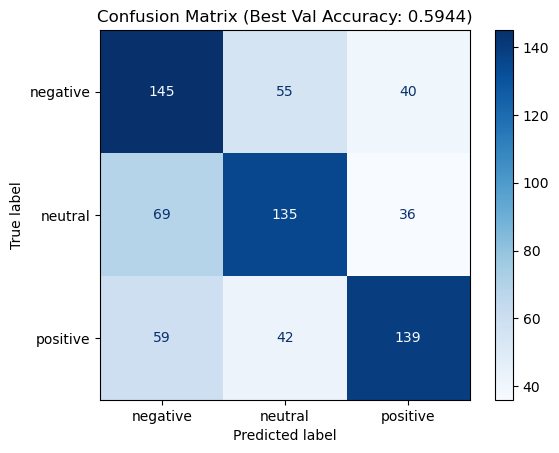

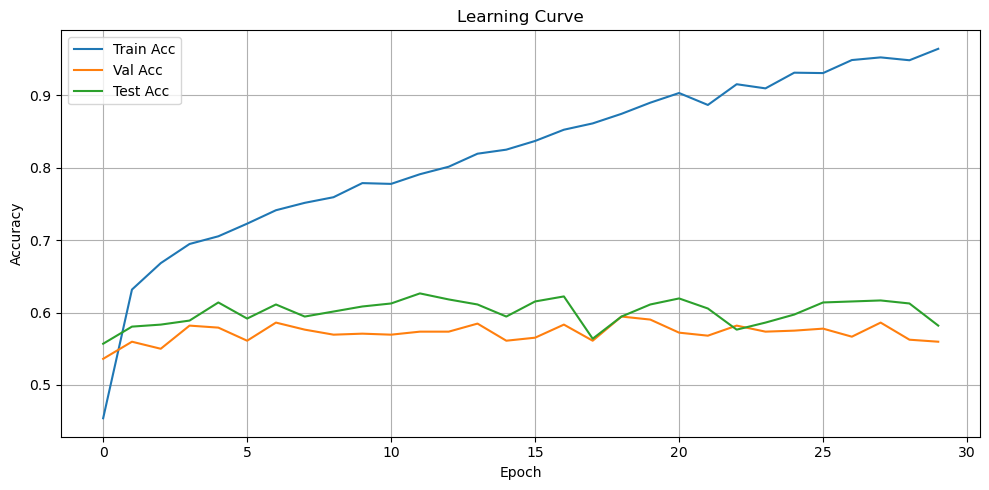

In [5]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

# ------------------- NLTK Setup -------------------
for resource in ['punkt', 'wordnet', 'averaged_perceptron_tagger']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource)

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('N'): return wordnet.NOUN
    elif tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def tokenize_text(text):
    tokens = word_tokenize(text.lower())
    return [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tag(tokens)]

# ------------------- Load Data -------------------
train_file = "/Users/tejamallireddy/Downloads/dynabench/train.csv"
val_file = "/Users/tejamallireddy/Downloads/dynabench/dev.csv"
test_file = "/Users/tejamallireddy/Downloads/dynabench/test.csv"

def load_data(train_file, val_file, test_file):
    train_df = pd.read_csv(train_file)[['text', 'label']].dropna()
    val_df = pd.read_csv(val_file)[['text', 'label']].dropna()
    test_df = pd.read_csv(test_file)[['text', 'label']].dropna()
    return train_df, val_df, test_df

data_train, data_val, data_test = load_data(train_file, val_file, test_file)

# ------------------- Preprocess -------------------
for df in [data_train, data_val, data_test]:
    df['tokenized_text'] = df['text'].apply(tokenize_text)
    df['untokenized_text'] = df['tokenized_text'].apply(lambda x: " ".join(x))

# ➕ TF-IDF (optional)
vectorizer = TfidfVectorizer(max_features=5000)
vectorizer.fit(data_train['untokenized_text'])

# ------------------- Build Vocabulary -------------------
def build_vocab(texts):
    vocab = {}
    for text in texts:
        for word in text:
            if word not in vocab:
                vocab[word] = len(vocab) + 1
    return vocab

vocab = build_vocab(data_train['tokenized_text'])

# ------------------- GloVe Embeddings -------------------
def load_glove_embeddings(glove_path, vocab, embed_dim=300):
    embeddings = np.random.uniform(-0.25, 0.25, (len(vocab) + 1, embed_dim))
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype='float32')
            idx = vocab.get(word)
            if idx is not None:
                embeddings[idx] = vector
    return torch.tensor(embeddings, dtype=torch.float32)

glove_path = "/Users/tejamallireddy/Downloads/glove.6B.300d.txt"
pretrained_embeddings = load_glove_embeddings(glove_path, vocab)

# ------------------- Dataset & Loader -------------------
def text_to_indices(text, vocab, max_length=150):
    indices = [vocab.get(word, 0) for word in text[:max_length]]
    return indices + [0] * (max_length - len(indices))

le = LabelEncoder()
data_train['label'] = le.fit_transform(data_train['label'])
data_val['label'] = le.transform(data_val['label'])
data_test['label'] = le.transform(data_test['label'])

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = [torch.tensor(text_to_indices(t, vocab)) for t in texts]
        self.labels = torch.tensor(labels)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.texts[idx], self.labels[idx]

train_dataset = SentimentDataset(data_train['tokenized_text'], data_train['label'], vocab)
val_dataset = SentimentDataset(data_val['tokenized_text'], data_val['label'], vocab)
test_dataset = SentimentDataset(data_test['tokenized_text'], data_test['label'], vocab)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)
test_loader = DataLoader(test_dataset, batch_size=128)

# ------------------- LSTM Model -------------------
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_dim, output_dim, n_layers=2, dropout=0.5, bidirectional=True):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.embedding.weight.data.copy_(pretrained_embeddings)
        self.embedding.weight.requires_grad = False

        self.lstm = nn.LSTM(input_size=embed_size,
                            hidden_size=hidden_dim,
                            num_layers=n_layers,
                            batch_first=True,
                            dropout=dropout,
                            bidirectional=bidirectional)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, (hidden, _) = self.lstm(x)
        if self.lstm.bidirectional:
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden = hidden[-1]
        hidden = self.dropout(hidden)
        return self.fc(hidden)

# ------------------- Training -------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = LSTMClassifier(len(vocab) + 1, 300, hidden_dim=256, output_dim=len(le.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0007, weight_decay=1e-4)

def train_model(model, train_loader, val_loader, test_loader, epochs=30):
    train_acc_list, val_acc_list, test_acc_list = [], [], []
    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_acc = correct / total
        train_acc_list.append(train_acc)

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        val_acc = val_correct / val_total
        val_acc_list.append(val_acc)
        best_val_acc = max(best_val_acc, val_acc)

        # Test
        test_correct, test_total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                test_correct += (preds == labels).sum().item()
                test_total += labels.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        test_acc = test_correct / test_total
        test_acc_list.append(test_acc)

        print(f"Epoch {epoch+1}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Best Val Accuracy: {best_val_acc:.4f})")
    plt.show()

    # Learning Curve
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc_list, label="Train Acc")
    plt.plot(val_acc_list, label="Val Acc")
    plt.plot(test_acc_list, label="Test Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Learning Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- Run -------------------
train_model(model, train_loader, val_loader, test_loader)


# yelp_dynabench_2500

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Epoch 1, Train Acc: 0.5474, Val Acc: 0.5944, Test Acc: 0.5743
Epoch 2, Train Acc: 0.6100, Val Acc: 0.5924, Test Acc: 0.5840
Epoch 3, Train Acc: 0.6296, Val Acc: 0.5958, Test Acc: 0.5826
Epoch 4, Train Acc: 0.6465, Val Acc: 0.6097, Test Acc: 0.6090
Epoch 5, Train Acc: 0.6572, Val Acc: 0.6146, Test Acc: 0.6222
Epoch 6, Train Acc: 0.6676, Val Acc: 0.6083, Test Acc: 0.6236
Epoch 7, Train Acc: 0.6775, Val Acc: 0.6181, Test Acc: 0.6153
Epoch 8, Train Acc: 0.6915, Val Acc: 0.6201, Test Acc: 0.6319
Epoch 9, Train Acc: 0.6992, Val Acc: 0.6062, Test Acc: 0.6375
Epoch 10, Train Acc: 0.7075, Val Acc: 0.6222, Test Acc: 0.6312
Epoch 11, Train Acc: 0.7185, Val Acc: 0.6146, Test Acc: 0.6285
Epoch 12, Train Acc: 0.7291, Val Acc: 0.6139, Test Acc: 0.6354
Epoch 13, Train Acc: 0.7347, Val Acc: 0.6076, Test Acc: 0.6361
Epoch 14, Train Acc: 0.7471, Val Acc: 0.6056, Test Acc: 0.6278
Epoch 15, Train Acc: 0.7612, Val Acc: 0.6257, Test Acc: 0.6500
Epoch 16, Train Acc: 0.7743, Val Acc: 0.6097, Test Acc: 0.6500
E

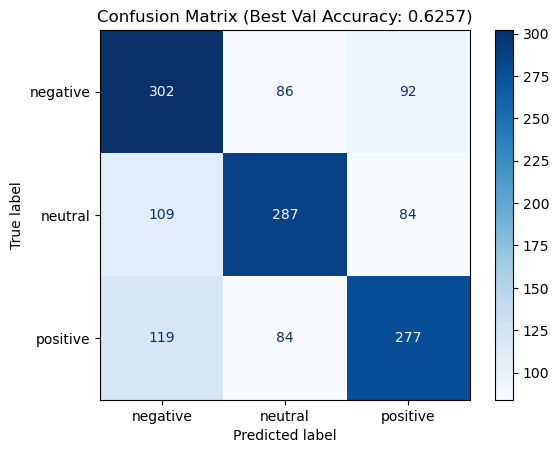

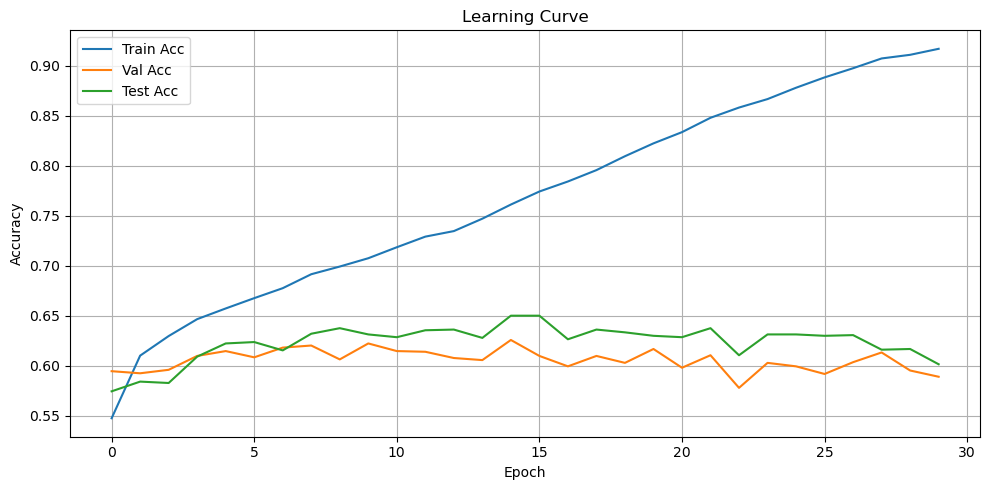

In [7]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

# ------------------- NLTK Setup -------------------
for resource in ['punkt', 'wordnet', 'averaged_perceptron_tagger']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource)

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('N'): return wordnet.NOUN
    elif tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def tokenize_text(text):
    tokens = word_tokenize(text.lower())
    return [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tag(tokens)]

# ------------------- Load Data -------------------
train_file = "/Users/tejamallireddy/Downloads/yelp_dynabench_2500/train.csv"
val_file = "/Users/tejamallireddy/Downloads/yelp_dynabench_2500/dev.csv"
test_file = "/Users/tejamallireddy/Downloads/yelp_dynabench_2500/test.csv"

def load_data(train_file, val_file, test_file):
    train_df = pd.read_csv(train_file)[['text', 'label']].dropna()
    val_df = pd.read_csv(val_file)[['text', 'label']].dropna()
    test_df = pd.read_csv(test_file)[['text', 'label']].dropna()
    return train_df, val_df, test_df

data_train, data_val, data_test = load_data(train_file, val_file, test_file)

# ------------------- Preprocess -------------------
for df in [data_train, data_val, data_test]:
    df['tokenized_text'] = df['text'].apply(tokenize_text)
    df['untokenized_text'] = df['tokenized_text'].apply(lambda x: " ".join(x))

# ➕ TF-IDF (optional)
vectorizer = TfidfVectorizer(max_features=5000)
vectorizer.fit(data_train['untokenized_text'])

# ------------------- Build Vocabulary -------------------
def build_vocab(texts):
    vocab = {}
    for text in texts:
        for word in text:
            if word not in vocab:
                vocab[word] = len(vocab) + 1
    return vocab

vocab = build_vocab(data_train['tokenized_text'])

# ------------------- GloVe Embeddings -------------------
def load_glove_embeddings(glove_path, vocab, embed_dim=300):
    embeddings = np.random.uniform(-0.25, 0.25, (len(vocab) + 1, embed_dim))
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype='float32')
            idx = vocab.get(word)
            if idx is not None:
                embeddings[idx] = vector
    return torch.tensor(embeddings, dtype=torch.float32)

glove_path = "/Users/tejamallireddy/Downloads/glove.6B.300d.txt"
pretrained_embeddings = load_glove_embeddings(glove_path, vocab)

# ------------------- Dataset & Loader -------------------
def text_to_indices(text, vocab, max_length=150):
    indices = [vocab.get(word, 0) for word in text[:max_length]]
    return indices + [0] * (max_length - len(indices))

le = LabelEncoder()
data_train['label'] = le.fit_transform(data_train['label'])
data_val['label'] = le.transform(data_val['label'])
data_test['label'] = le.transform(data_test['label'])

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = [torch.tensor(text_to_indices(t, vocab)) for t in texts]
        self.labels = torch.tensor(labels)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.texts[idx], self.labels[idx]

train_dataset = SentimentDataset(data_train['tokenized_text'], data_train['label'], vocab)
val_dataset = SentimentDataset(data_val['tokenized_text'], data_val['label'], vocab)
test_dataset = SentimentDataset(data_test['tokenized_text'], data_test['label'], vocab)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)
test_loader = DataLoader(test_dataset, batch_size=128)

# ------------------- LSTM Model -------------------
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_dim, output_dim, n_layers=2, dropout=0.5, bidirectional=True):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.embedding.weight.data.copy_(pretrained_embeddings)
        self.embedding.weight.requires_grad = False

        self.lstm = nn.LSTM(input_size=embed_size,
                            hidden_size=hidden_dim,
                            num_layers=n_layers,
                            batch_first=True,
                            dropout=dropout,
                            bidirectional=bidirectional)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, (hidden, _) = self.lstm(x)
        if self.lstm.bidirectional:
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden = hidden[-1]
        hidden = self.dropout(hidden)
        return self.fc(hidden)

# ------------------- Training -------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = LSTMClassifier(len(vocab) + 1, 300, hidden_dim=256, output_dim=len(le.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0007, weight_decay=1e-4)

def train_model(model, train_loader, val_loader, test_loader, epochs=30):
    train_acc_list, val_acc_list, test_acc_list = [], [], []
    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_acc = correct / total
        train_acc_list.append(train_acc)

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        val_acc = val_correct / val_total
        val_acc_list.append(val_acc)
        best_val_acc = max(best_val_acc, val_acc)

        # Test
        test_correct, test_total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                test_correct += (preds == labels).sum().item()
                test_total += labels.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        test_acc = test_correct / test_total
        test_acc_list.append(test_acc)

        print(f"Epoch {epoch+1}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Best Val Accuracy: {best_val_acc:.4f})")
    plt.show()

    # Learning Curve
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc_list, label="Train Acc")
    plt.plot(val_acc_list, label="Val Acc")
    plt.plot(test_acc_list, label="Test Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Learning Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- Run -------------------
train_model(model, train_loader, val_loader, test_loader)
